In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
returns = pd.read_csv(
    "../data/processed/10_industry_monthly_returns.csv",
    index_col="Date",
    parse_dates=True
)

returns.head()

,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
Date,,,,,,,,,,
1926-07-01,0.0144,0.1390,0.0470,-0.0114,0.0290,0.0083,0.0012,0.0185,0.0704,0.0214
1926-08-01,0.0399,0.0370,0.0280,0.0343,0.0266,0.0217,-0.0072,0.0417,-0.0170,0.0435
1926-09-01,0.0115,0.0498,0.0117,-0.0330,-0.0039,0.0242,0.0021,0.0069,0.0205,0.0031
1926-10-01,-0.0124,-0.0839,-0.0365,-0.0078,-0.0458,-0.0011,-0.0229,-0.0057,-0.0327,-0.0285
1926-11-01,0.0521,-0.0017,0.0427,0.0001,0.0471,0.0163,0.0645,0.0543,0.0440,0.0213


In [4]:
#checks

print("shape:", returns.shape)
print("start date:", returns.index.min())
print("end date:", returns.index.max())


shape: (1197, 10)
start date: 1926-07-01 00:00:00
end date: 2026-03-01 00:00:00


### Rolling window

window size 120 months

In [7]:
window_size = 120

In [8]:
# modular get equal weights
# creates the 1/n weights. window_returns is the past data window, then find how many assets


def get_equal_weights(window_returns):
    
    N = window_returns.shape[1]
    
    weights = np.repeat(1 / N, N)
    
    return weights



In [10]:
#test 
test_window = returns.iloc[:window_size]

test_weights = get_equal_weights(test_window)

test_weights

array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])

In [11]:
test_weights.sum()

np.float64(1.0)

## Rolling Backtest


In [12]:
portfolio_returns = []
portfolio_dates = []
portfolio_weights = []


for i in range(window_size, len(returns)):
    
    #past 120 months of data
    window_returns = returns.iloc[i - window_size:i]
    
    #next month return (month we are predicting)
    next_month_return = returns.iloc[i]
    
    #portfolio weights
    weights = get_equal_weights(window_returns)
    
    #calculate portfolio return for the next month
    portfolio_return = next_month_return @ weights

    
    portfolio_returns.append(portfolio_return)
    portfolio_dates.append(returns.index[i])
    portfolio_weights.append(weights)

In [14]:
rolling_returns = pd.Series(
    portfolio_returns,
    index=portfolio_dates,
    name="1/N Rolling Portfolio"
)

rolling_returns.head()

1936-07-01    0.06709
1936-08-01    0.00756
1936-09-01    0.00705
1936-10-01    0.06808
1936-11-01    0.03134
Name: 1/N Rolling Portfolio, dtype: float64

In [15]:
#check if all weights add to 0

rolling_weights = pd.DataFrame(
    portfolio_weights,
    index=portfolio_dates,
    columns=returns.columns
)

rolling_weights.head()

,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
1936-07-01,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
1936-08-01,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
1936-09-01,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
1936-10-01,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
1936-11-01,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1


In [17]:
rolling_weights.sum(axis=1).head()

1936-07-01    1.0
1936-08-01    1.0
1936-09-01    1.0
1936-10-01    1.0
1936-11-01    1.0
dtype: float64

## Calculate cummulative wealth

10 dollars invested

In [21]:
rolling_wealth = (1 + rolling_returns).cumprod()

rolling_wealth.head()

1936-07-01    1.067090
1936-08-01    1.075157
1936-09-01    1.082737
1936-10-01    1.156450
1936-11-01    1.192693
Name: 1/N Rolling Portfolio, dtype: float64

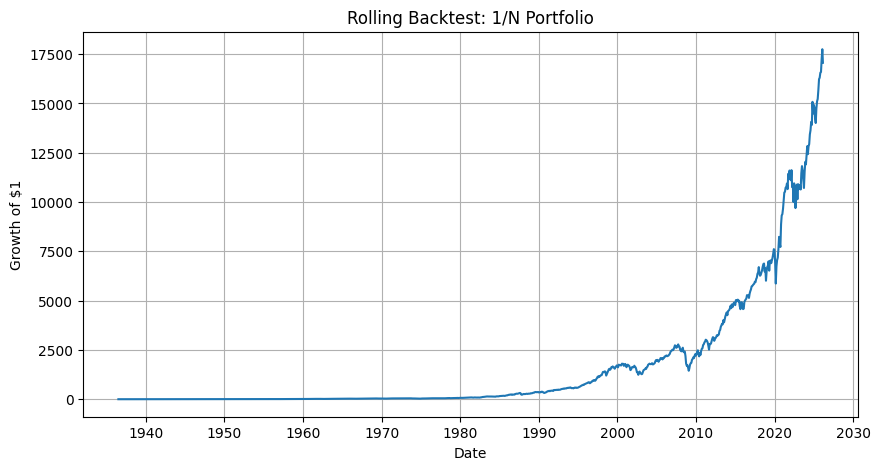

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(rolling_wealth)

plt.title("Rolling Backtest: 1/N Portfolio")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)

plt.savefig("../outputs/figures/rolling_one_over_n_cumulative_wealth.png", dpi=300)


plt.show()


In [24]:
avg_monthly_return = rolling_returns.mean()
monthly_volatility = rolling_returns.std()
monthly_sharpe = avg_monthly_return / monthly_volatility

annualized_return = (1 + avg_monthly_return) ** 12 - 1
annualized_volatility = monthly_volatility * np.sqrt(12)
annualized_sharpe = monthly_sharpe * np.sqrt(12)

print("Average Monthly Return:", avg_monthly_return)
print("Monthly Volatility:", monthly_volatility)
print("Monthly Sharpe:", monthly_sharpe)
print("Annualized Return:", annualized_return)
print("Annualized Volatility:", annualized_volatility)
print("Annualized Sharpe:", annualized_sharpe)

Average Monthly Return: 0.010030185701021354
Monthly Volatility: 0.04320262167801809
Monthly Sharpe: 0.23216613509649137
Annualized Return: 0.12722922334178732
Annualized Volatility: 0.14965827153300781
Annualized Sharpe: 0.8042470835680459


In [25]:
summary = pd.DataFrame({
    "Strategy": ["1/N Rolling Equal Weight"],
    "Window Size": [window_size],
    "Avg Monthly Return": [avg_monthly_return],
    "Monthly Volatility": [monthly_volatility],
    "Monthly Sharpe": [monthly_sharpe],
    "Annualized Return": [annualized_return],
    "Annualized Volatility": [annualized_volatility],
    "Annualized Sharpe": [annualized_sharpe]
})

summary

,Strategy,Window Size,Avg Monthly Return,Monthly Volatility,Monthly Sharpe,Annualized Return,Annualized Volatility,Annualized Sharpe
0,1/N Rolling Equal Weight,120,0.01003,0.043203,0.232166,0.127229,0.149658,0.804247


In [32]:
rolling_returns.to_csv("../outputs/tables/rolling_one_over_n_returns.csv")
rolling_weights.to_csv("../outputs/tables/rolling_one_over_n_weights.csv")
summary.to_csv("../outputs/tables/rolling_one_over_n_summary.csv", index=False)

## Findings

For 1/N rolling window doesn't really make any difference because all the weights remain the same.